# Volatility Smiles — OMXS30 Call Options
## Financial Mathematics Seminar Project

**Evaluation Date:** 2026-05-12 | **S₀** = 3046.71 | **r** = 5%

This notebook computes implied volatility smiles for OMXS30 European call options
using the Black-Scholes-Merton model and Newton-Raphson root finding.

## Imports & Configuration

In [1]:
# ── Standard Library ──
import math
from math import log, sqrt, exp
import datetime
import logging

# ── Third-Party ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ── Logging Configuration ──
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-7s | %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger('VolSmile')

# ── Matplotlib Professional Styling ──
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 1.8,
    'lines.markersize': 6,
})

logger.info("Imports and configuration loaded successfully.")

22:39:16 | INFO    | Imports and configuration loaded successfully.


## Global Constants

In [2]:
# ── Global Constants (Locked — see core/instructions/general.md) ──
EVALUATION_DATE = '2026-05-12'
S0 = 3046.71            # OMXS30 spot price on evaluation date
r = 0.05                # Risk-free rate (continuously compounded, annualized)
TRADING_DAYS_YEAR = 252  # Standard trading-day convention

# ── Data File Paths ──
DATA_DIR = '../data'
SHORT_MATURITY_FILE = f'{DATA_DIR}/OMXS30_DownloadDate_2026-05-12_ExpiryDate_2026-06-12.csv'
LONG_MATURITY_FILE  = f'{DATA_DIR}/OMXS30_DownloadDate_2026-05-12_ExpiryDate_2026-07-17.csv'

# ── Expiry Dates ──
SHORT_EXPIRY = '2026-06-12'
LONG_EXPIRY  = '2026-07-17'

# ── Seed Fallback Cascade (Rule 3) ──
SEED_CASCADE = [0.20, 0.05, 0.50]

logger.info(f"Constants: S0={S0}, r={r}, Eval={EVALUATION_DATE}")
logger.info(f"Short expiry: {SHORT_EXPIRY}, Long expiry: {LONG_EXPIRY}")

22:39:16 | INFO    | Constants: S0=3046.71, r=0.05, Eval=2026-05-12
22:39:16 | INFO    | Short expiry: 2026-06-12, Long expiry: 2026-07-17


## BSM Functions (Professor's — Source of Truth)

> **These three functions are copied verbatim from `core/src/main.ipynb`.**
> They must NOT be modified. Safety wrappers are defined in the next section.

In [3]:
from math import log, sqrt, exp
from scipy import stats

# Analytical Black-Scholes-Merton (BSM) Formula
def bsm_call_value(S0, K, T, r, sigma):
    ''' Valuation of European call option in BSM model.
    Analytical formula.
    Parameters
    ==========
    S0 : float
    initial stock/index level
    K : float
    strike price
    T : float
    maturity date (in year fractions)
    r : float
    constant risk-free short rate
    sigma : float
    volatility factor in diffusion term
    Returns
    =======
    value : float
    Price of European call option ati time 0
    '''

    S0 = float(S0)
    d1 = (log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrt(T))
    # print(f'{d1 = }')
    d2 = (log(S0 / K) + (r - 0.5 * sigma ** 2) * T) / (sigma * sqrt(T))
    # print(f'{d2 = }')
    value = (S0 * stats.norm.cdf(d1, 0.0, 1.0)- K * exp(-r * T) * stats.norm.cdf(d2, 0.0, 1.0))
    # stats.norm.cdf --> cumulative distribution function for normal distribution
    # print('N(d1) =', stats.norm.cdf(d1, 0.0, 1.0))
    # print('N(d2) =', stats.norm.cdf(d2, 0.0, 1.0))

    return value

# Vega function (derivative of the BSM function above)
def bsm_vega(S0, K, T, r, sigma):
    ''' Vega of European option in BSM model.        '''

    S0 = float(S0)
    d1 = (log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrt(T))
    vega = S0 * stats.norm.pdf(d1, 0.0, 1.0) * sqrt(T)
    return vega

# Implied volatility, need both the call value function and the vega function

# STUDENTS: Please read more on Newton-Raphson method for solving non-linear equations
def bsm_call_imp_vol(S0, K, T, r, C0, sigma_est, it=100):
    ''' Implied volatility of European call option in BSM model, using Newton-Raphson method
    Parameters
    ==========
    S0 : float
    initial stock/index level
    K : float
    strike price
    T : float
    maturity date (in year fractions)
    r : float
    constant risk-free short rate
    C0: float
    market option price
    sigma_est : float
    estimate of impl. volatility
    it : integer,  number of iterations

    Returns
    =======
    simga_est : float
    numerically estimated implied volatility
    '''
    for i in range(it):
        sigma_est -= ((bsm_call_value(S0, K, T, r, sigma_est) - C0)/bsm_vega(S0, K, T, r, sigma_est))

    return sigma_est

logger.info("BSM functions loaded (professor's verbatim copies).")

22:39:16 | INFO    | BSM functions loaded (professor's verbatim copies).


## Safety Wrappers (Rules 2 & 3)

These wrappers handle convergence failures without modifying the professor's functions.

In [4]:
def bsm_call_imp_vol_safe(S0, K, T, r, C0, sigma_est, it=100):
    """Safe wrapper around professor's IV solver with error handling.

    Implements Rule 2 (Convergence Safety): catches solver failures
    from division by zero (vega ≈ 0) or math domain errors.

    Args:
        S0: Spot price.
        K: Strike price.
        T: Time to maturity (trading-day year fractions).
        r: Risk-free rate.
        C0: Market option price.
        sigma_est: Initial volatility estimate (seed).
        it: Maximum Newton-Raphson iterations.

    Returns:
        Implied volatility (float) if converged, None otherwise.
    """
    try:
        sigma = bsm_call_imp_vol(S0, K, T, r, C0, sigma_est, it)
        if sigma is not None and np.isfinite(sigma) and sigma > 0:
            return sigma
        return None
    except (ZeroDivisionError, ValueError, OverflowError) as e:
        logger.warning(f"IV solver failed for K={K}, seed={sigma_est}: {e}")
        return None


def solve_iv_with_fallback(S0, K, T, r, C0):
    """Attempt IV solve with multiple initial guesses before discarding.

    Implements Rule 3 (Seed Fallback Strategy): tries seeds [0.20, 0.05, 0.50]
    in sequence. Only discards the strike after all three fail.

    Args:
        S0: Spot price.
        K: Strike price.
        T: Time to maturity (trading-day year fractions).
        r: Risk-free rate.
        C0: Market option price.

    Returns:
        Implied volatility (float) if any seed converges, np.nan otherwise.
    """
    for seed in SEED_CASCADE:
        result = bsm_call_imp_vol_safe(S0, K, T, r, C0, seed)
        if result is not None:
            return result
    logger.warning(f"All seeds failed for K={K}. Discarding strike.")
    return np.nan

logger.info("Safety wrappers initialized (seed cascade: %s).", SEED_CASCADE)

22:39:16 | INFO    | Safety wrappers initialized (seed cascade: [0.2, 0.05, 0.5]).


## Data Loading Function

In [5]:
def load_options_data(filepath):
    """Load and clean OMXS30 options CSV per data_processing.md rules.

    Handles Nasdaq OMX CSV quirks: sep=';' header line, quoted Strike
    column with comma thousands separators, and coerces numeric columns.
    Computes C0 via the mandatory 3-priority cascade (Rule 1).

    Args:
        filepath: Path to the CSV file.

    Returns:
        Cleaned DataFrame with columns including Strike, Bid, Ask, Last, C0.
    """
    # ── 1. Read CSV (semicolon-separated, skip 'sep=;' first line) ──
    df = pd.read_csv(filepath, sep=';', skiprows=1)
    logger.info(f"Loaded {len(df)} rows from {filepath}")

    # ── 2. Clean Strike column: remove quotes and comma thousands separator ──
    df['Strike'] = (
        df['Strike']
        .astype(str)
        .str.replace('"', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
    )

    # ── 3. Coerce numeric columns to float (invalid → NaN) ──
    numeric_cols = ['Bid', 'Ask', 'Last', 'High', 'Low', 'Open Interest', 'Volume']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # ── 4. Market Price Calculation — Rule 1 (C0 Priority Cascade) ──
    # Priority 1: Mid-price from Bid/Ask if both exist and > 0
    has_bid_ask = (
        df['Bid'].notna() & (df['Bid'] > 0) &
        df['Ask'].notna() & (df['Ask'] > 0)
    )
    df['C0'] = np.where(has_bid_ask, (df['Bid'] + df['Ask']) / 2.0, np.nan)

    mid_count = has_bid_ask.sum()

    # Priority 2: Fall back to Last if Mid is not available
    has_last = df['Last'].notna() & (df['Last'] > 0)
    fallback_mask = df['C0'].isna() & has_last
    df['C0'] = np.where(fallback_mask, df['Last'], df['C0'])

    last_count = fallback_mask.sum()

    # Priority 3: Drop rows where C0 is still NaN (no pricing data)
    pre_drop = len(df)
    df = df[df['C0'].notna()].copy()
    dropped = pre_drop - len(df)

    # ── 5. Log pricing source breakdown ──
    logger.info(
        f"C0 sources — Mid-price: {mid_count}, Last fallback: {last_count}, "
        f"Dropped (no data): {dropped}"
    )
    logger.info(f"Final dataset: {len(df)} rows with valid C0")

    return df

## Load Short Maturity Data (Expiry: 2026-06-12)

In [6]:
df_short = load_options_data(SHORT_MATURITY_FILE)
df_short = df_short.sort_values('Strike').reset_index(drop=True)
logger.info(f"Short maturity: {len(df_short)} strikes from {df_short['Strike'].min():.0f} to {df_short['Strike'].max():.0f}")
df_short[['Name', 'Strike', 'Bid', 'Ask', 'Last', 'C0']].head(10)

22:39:16 | INFO    | Loaded 52 rows from ../data/OMXS30_DownloadDate_2026-05-12_ExpiryDate_2026-06-12.csv
22:39:16 | INFO    | C0 sources — Mid-price: 52, Last fallback: 0, Dropped (no data): 0
22:39:16 | INFO    | Final dataset: 52 rows with valid C0
22:39:16 | INFO    | Short maturity: 52 strikes from 2800 to 3310


,Name,Strike,Bid,Ask,Last,C0
0,OMXS306F12Y2800,2800.0,253.00,267.75,NaN,260.375
1,OMXS306F12Y2810,2810.0,245.50,257.00,NaN,251.250
2,OMXS306F12Y2820,2820.0,236.25,248.00,NaN,242.125
3,OMXS306F12Y2830,2830.0,227.25,238.75,NaN,233.000
4,OMXS306F12Y2840,2840.0,218.00,229.75,NaN,223.875
5,OMXS306F12Y2850,2850.0,209.00,220.75,NaN,214.875
6,OMXS306F12Y2860,2860.0,200.25,212.00,NaN,206.125
7,OMXS306F12Y2870,2870.0,191.50,203.00,NaN,197.250
8,OMXS306F12Y2880,2880.0,182.75,194.50,NaN,188.625
9,OMXS306F12Y2890,2890.0,174.00,185.75,NaN,179.875


## Load Long Maturity Data (Expiry: 2026-07-17)

In [7]:
df_long = load_options_data(LONG_MATURITY_FILE)
df_long = df_long.sort_values('Strike').reset_index(drop=True)
logger.info(f"Long maturity: {len(df_long)} strikes from {df_long['Strike'].min():.0f} to {df_long['Strike'].max():.0f}")
df_long[['Name', 'Strike', 'Bid', 'Ask', 'Last', 'C0']].head(10)

22:39:16 | INFO    | Loaded 43 rows from ../data/OMXS30_DownloadDate_2026-05-12_ExpiryDate_2026-07-17.csv
22:39:16 | INFO    | C0 sources — Mid-price: 43, Last fallback: 0, Dropped (no data): 0
22:39:16 | INFO    | Final dataset: 43 rows with valid C0
22:39:16 | INFO    | Long maturity: 43 strikes from 2640 to 3480


,Name,Strike,Bid,Ask,Last,C0
0,OMXS306G2640,2640.0,418.50,436.25,NaN,427.375
1,OMXS306G2660,2660.0,403.50,415.25,NaN,409.375
2,OMXS306G2680,2680.0,385.00,396.75,NaN,390.875
3,OMXS306G2700,2700.0,366.50,377.00,385.0,371.750
4,OMXS306G2720,2720.0,348.25,359.75,377.0,354.000
5,OMXS306G2740,2740.0,330.00,341.75,NaN,335.875
6,OMXS306G2760,2760.0,312.00,323.75,NaN,317.875
7,OMXS306G2780,2780.0,294.25,306.00,NaN,300.125
8,OMXS306G2800,2800.0,276.75,288.50,NaN,282.625
9,OMXS306G2820,2820.0,259.50,271.25,375.0,265.375


## Time-to-Maturity Calculation

Using `np.busday_count` to count trading days (excludes weekends).
T = trading_days / 252 (trading-day convention, **not** calendar days / 365).

In [8]:
# ── Time-to-Maturity: T = trading_days / 252 ──
eval_date = np.datetime64(EVALUATION_DATE)

# Short maturity
exp_short = np.datetime64(SHORT_EXPIRY)
trading_days_short = np.busday_count(eval_date, exp_short)
T_short = trading_days_short / TRADING_DAYS_YEAR

# Long maturity
exp_long = np.datetime64(LONG_EXPIRY)
trading_days_long = np.busday_count(eval_date, exp_long)
T_long = trading_days_long / TRADING_DAYS_YEAR

logger.info(
    f"Short maturity: {trading_days_short} trading days → T = {T_short:.6f} years "
    f"(expiry {SHORT_EXPIRY})"
)
logger.info(
    f"Long maturity:  {trading_days_long} trading days → T = {T_long:.6f} years "
    f"(expiry {LONG_EXPIRY})"
)

22:39:16 | INFO    | Short maturity: 23 trading days → T = 0.091270 years (expiry 2026-06-12)
22:39:16 | INFO    | Long maturity:  48 trading days → T = 0.190476 years (expiry 2026-07-17)


## Implied Volatility Computation

For each strike, solve for σ such that $C^{BS}(S_0, K, T, r, \sigma) = C_0$
using Newton-Raphson with seed fallback cascade.

In [9]:
def compute_iv_for_dataset(df, T, label):
    """Compute implied volatilities for all strikes in a DataFrame.

    Args:
        df: DataFrame with Strike and C0 columns.
        T: Time to maturity (trading-day year fractions).
        label: Label for logging (e.g. 'Short' or 'Long').

    Returns:
        DataFrame with columns Strike, C0, IV (NaN-free).
    """
    results = []
    failed_count = 0

    for _, row in df.iterrows():
        K = row['Strike']
        C0_val = row['C0']
        iv = solve_iv_with_fallback(S0, K, T, r, C0_val)

        if np.isfinite(iv):
            results.append({'Strike': K, 'C0': C0_val, 'IV': iv})
        else:
            failed_count += 1

    df_result = pd.DataFrame(results)
    logger.info(
        f"{label} maturity: {len(df_result)} IVs computed, "
        f"{failed_count} strikes discarded"
    )
    return df_result


# ── Compute IV for both maturities ──
logger.info("=" * 60)
logger.info("Computing implied volatilities — Short Maturity")
logger.info("=" * 60)
iv_short = compute_iv_for_dataset(df_short, T_short, 'Short')

logger.info("=" * 60)
logger.info("Computing implied volatilities — Long Maturity")
logger.info("=" * 60)
iv_long = compute_iv_for_dataset(df_long, T_long, 'Long')

22:39:16 | INFO    | ============================================================
22:39:16 | INFO    | Computing implied volatilities — Short Maturity
22:39:16 | INFO    | ============================================================
22:39:17 | INFO    | Short maturity: 52 IVs computed, 0 strikes discarded
22:39:17 | INFO    | ============================================================
22:39:17 | INFO    | Computing implied volatilities — Long Maturity
22:39:17 | INFO    | ============================================================
/var/folders/ml/xkvgsfsd6px2j4560wfj3g_r0000gn/T/ipykernel_26425/4062401015.py:74: RuntimeWarning: divide by zero encountered in scalar divide
  sigma_est -= ((bsm_call_value(S0, K, T, r, sigma_est) - C0)/bsm_vega(S0, K, T, r, sigma_est))
/var/folders/ml/xkvgsfsd6px2j4560wfj3g_r0000gn/T/ipykernel_26425/4062401015.py:27: RuntimeWarning: invalid value encountered in scalar divide
  d1 = (log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrt(T))
/var/folde

## Plot 1: Short Maturity Volatility Smile

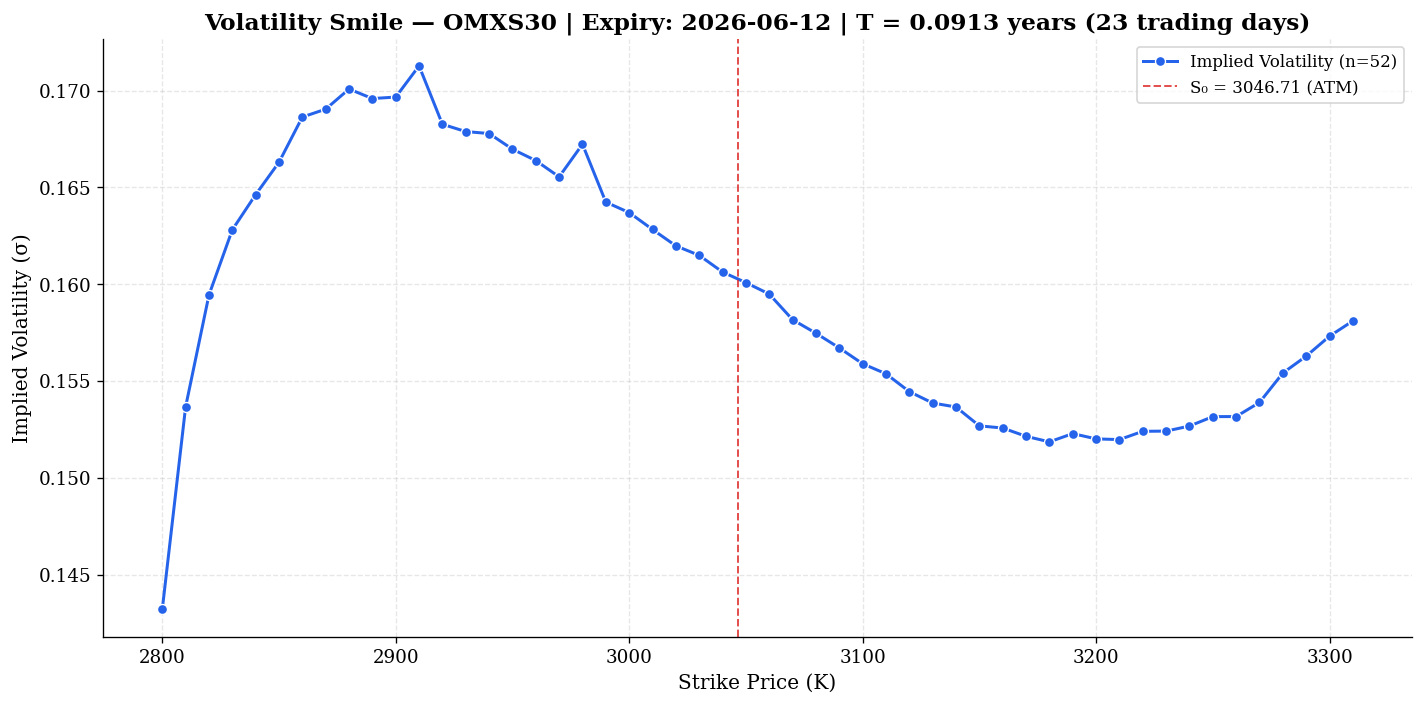

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    iv_short['Strike'], iv_short['IV'],
    'o-', color='#2563EB', markeredgecolor='white', markeredgewidth=0.8,
    label=f'Implied Volatility (n={len(iv_short)})'
)

# ── ATM reference line at S0 ──
ax.axvline(
    x=S0, color='#DC2626', linestyle='--', linewidth=1.2, alpha=0.8,
    label=f'S₀ = {S0:.2f} (ATM)'
)

ax.set_title(
    f'Volatility Smile — OMXS30 | Expiry: {SHORT_EXPIRY} | '
    f'T = {T_short:.4f} years ({trading_days_short} trading days)'
)
ax.set_xlabel('Strike Price (K)')
ax.set_ylabel('Implied Volatility (σ)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## Plot 2: Long Maturity Volatility Smile

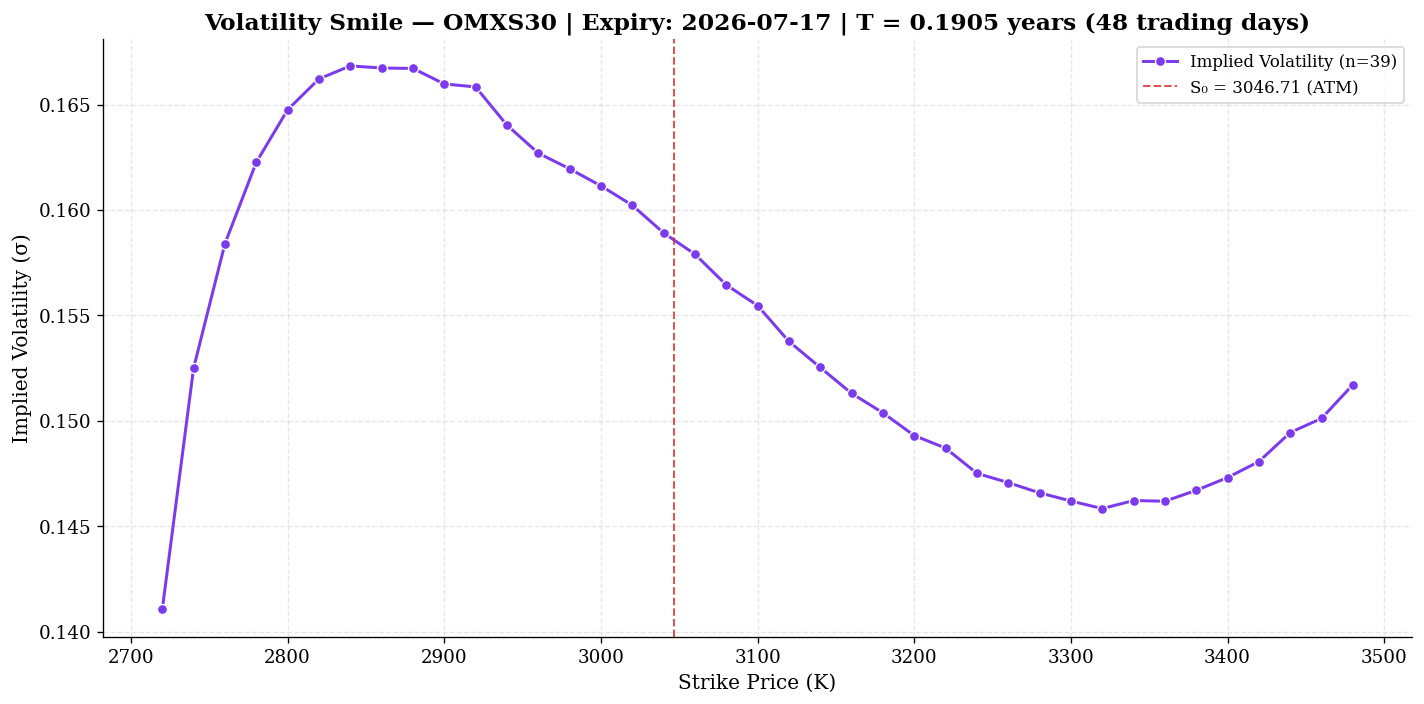

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    iv_long['Strike'], iv_long['IV'],
    'o-', color='#7C3AED', markeredgecolor='white', markeredgewidth=0.8,
    label=f'Implied Volatility (n={len(iv_long)})'
)

# ── ATM reference line at S0 ──
ax.axvline(
    x=S0, color='#DC2626', linestyle='--', linewidth=1.2, alpha=0.8,
    label=f'S₀ = {S0:.2f} (ATM)'
)

ax.set_title(
    f'Volatility Smile — OMXS30 | Expiry: {LONG_EXPIRY} | '
    f'T = {T_long:.4f} years ({trading_days_long} trading days)'
)
ax.set_xlabel('Strike Price (K)')
ax.set_ylabel('Implied Volatility (σ)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## Summary Tables

In [12]:
# ── Format IV results for display ──
def format_iv_table(df_iv, label):
    """Format IV results with readable column names and percentage display.

    Args:
        df_iv: DataFrame with Strike, C0, IV columns.
        label: Maturity label for the header.

    Returns:
        Styled DataFrame for display.
    """
    display_df = df_iv.copy()
    display_df['IV (%)'] = (display_df['IV'] * 100).round(2)
    display_df['C0'] = display_df['C0'].round(2)
    display_df['Strike'] = display_df['Strike'].astype(int)
    return display_df[['Strike', 'C0', 'IV (%)']]


logger.info("\n" + "=" * 60)
logger.info("SUMMARY — Short Maturity (Expiry: %s, T=%.4f)", SHORT_EXPIRY, T_short)
logger.info("=" * 60)
short_table = format_iv_table(iv_short, 'Short')
display(short_table)

logger.info("\n" + "=" * 60)
logger.info("SUMMARY — Long Maturity (Expiry: %s, T=%.4f)", LONG_EXPIRY, T_long)
logger.info("=" * 60)
long_table = format_iv_table(iv_long, 'Long')
display(long_table)

logger.info("Pipeline complete. Both volatility smiles computed successfully.")

22:39:18 | INFO    | 
22:39:18 | INFO    | SUMMARY — Short Maturity (Expiry: 2026-06-12, T=0.0913)
22:39:18 | INFO    | ============================================================


,Strike,C0,IV (%)
0,2800,260.38,14.32
1,2810,251.25,15.37
2,2820,242.12,15.94
3,2830,233.00,16.28
4,2840,223.88,16.46
5,2850,214.88,16.63
6,2860,206.12,16.86
7,2870,197.25,16.90
8,2880,188.62,17.01
9,2890,179.88,16.96


22:39:18 | INFO    | 
22:39:18 | INFO    | SUMMARY — Long Maturity (Expiry: 2026-07-17, T=0.1905)
22:39:18 | INFO    | ============================================================


,Strike,C0,IV (%)
0,2720,354.00,14.11
1,2740,335.88,15.25
2,2760,317.88,15.84
3,2780,300.12,16.23
4,2800,282.62,16.48
5,2820,265.38,16.62
6,2840,248.38,16.68
7,2860,231.62,16.67
8,2880,215.38,16.67
9,2900,199.38,16.60


22:39:18 | INFO    | Pipeline complete. Both volatility smiles computed successfully.
